In [1]:
# ============================
# Imports & Setup
# ============================

import os
from pathlib import Path

# If the kernel cwd is the parent folder, move into the folder that holds CSV + NetCDF
_here = Path.cwd()
if not (_here / "malaria_cases.csv").exists():
    _inner = _here / "malaria.project"
    if (_inner / "malaria_cases.csv").exists():
        os.chdir(_inner)
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib
from IPython.display import display

# Display settings for readability
pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

# Paths
DATA_PATH = "malaria_cases.csv"  # <-- CSV dataset path
CLIMATE_FEATURES_PATH = os.path.join("outputs", "climate_avgua_by_year_m49.csv")
OUTPUT_DIR = "outputs"
MODEL_PATH = os.path.join(OUTPUT_DIR, "malaria_outbreak_random_forest.joblib")

os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = "outbreak"
THRESHOLD_RATE = 50  # threshold for automatic outbreak creation (RATE_PER_1000_NL > 50)

## Climate features from NetCDF

1. Run the **next** cell once to install **xarray** and **netCDF4** into *this* notebook kernel (`%pip` targets the kernel, not only your terminal Python).
2. Then run the extraction cell: same logic as `extract_climate_features.py` — reads `data_stream-moda_stepType-avgua.nc`, writes CSVs under `outputs/`, and refreshes `climate_avgua_by_year_m49.csv`.


In [2]:
# Install NetCDF stack into this Jupyter kernel (safe to re-run)
%pip install -q xarray netCDF4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Same logic as extract_climate_features.py — builds outputs used below
import extract_climate_features as _ec

if os.path.isfile(_ec.NC_DEFAULT):
    _ec.main()
else:
    print(
        f"Skipping climate extraction: NetCDF not found at {_ec.NC_DEFAULT!r}.\n"
        "If outputs/climate_avgua_by_year_m49.csv already exists, the next cell will merge it."
    )

Wrote monthly domain series: outputs\climate_avgua_t2m_monthly_domain_mean.csv
Wrote domain yearly features: outputs\climate_avgua_domain_by_year.csv
Wrote malaria merge table (year x M49): outputs\climate_avgua_by_year_m49.csv
Wrote yearly gridded t2m (C): outputs\data_stream_avgua_t2m_yearly_gridded.csv


## Load dataset + merge climate

After running the climate extraction cells above (so `outputs/climate_avgua_by_year_m49.csv` exists), we:

- Load `malaria_cases.csv`.
- Left-merge ERA5 temperature features on `DIM_TIME` and `DIM_GEO_CODE_M49`.
- Inspect the first rows (including `climate_*` columns when present).
- Confirm `RATE_PER_1000_NL` exists for building the `outbreak` target.

In [4]:
# ============================
# Load Dataset
# ============================

# Load CSV into DataFrame
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Please ensure the CSV file is placed in the working directory."
    )

df = pd.read_csv(DATA_PATH)

if os.path.isfile(CLIMATE_FEATURES_PATH):
    climate_df = pd.read_csv(CLIMATE_FEATURES_PATH)
    df = df.merge(
        climate_df,
        left_on=["DIM_TIME", "DIM_GEO_CODE_M49"],
        right_on=["year", "m49"],
        how="left",
    )
    df = df.drop(columns=["year", "m49"])
    print(
        f"Merged climate features from '{CLIMATE_FEATURES_PATH}' "
        f"(rows still {len(df)})."
    )
else:
    print(
        f"Note: '{CLIMATE_FEATURES_PATH}' not found. "
        "Run the climate extraction cell above after adding the NetCDF."
    )

print(f"Loaded dataset from '{DATA_PATH}' with shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

# Check for required column used to create 'outbreak'
if "RATE_PER_1000_NL" not in df.columns:
    raise ValueError(
        "Column 'RATE_PER_1000_NL' not found in dataset. "
        "This column is required to automatically create the 'outbreak' target."
    )

Merged climate features from 'outputs\climate_avgua_by_year_m49.csv' (rows still 2710).
Loaded dataset from 'malaria_cases.csv' with shape: (2710, 19)

First 5 rows:


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_1000_N,RATE_PER_1000_NL,RATE_PER_1000_NU,climate_t2m_domain_mean_c,climate_t2m_domain_std_monthly_c,climate_t2m_domain_min_monthly_c,climate_t2m_domain_max_monthly_c,climate_t2m_local_mean_c
0,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,364,COUNTRY,PUBLISHED,Malaria cases,Iran (Islamic Republic of),28.028820,28.028820,28.028820,24.855484,0.917594,23.585876,26.172485,NaN
1,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,368,COUNTRY,PUBLISHED,Malaria cases,Iraq,0.386175,0.386175,0.386175,24.855484,0.917594,23.585876,26.172485,NaN
2,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,384,COUNTRY,PUBLISHED,Malaria cases,Côte d'Ivoire,502.600348,402.149343,621.624666,24.855484,0.917594,23.585876,26.172485,26.588327
3,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,404,COUNTRY,PUBLISHED,Malaria cases,Kenya,245.449643,195.614445,303.733246,24.855484,0.917594,23.585876,26.172485,25.672964
4,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,408,COUNTRY,PUBLISHED,Malaria cases,Democratic People's Republic of Korea,12.418067,12.418067,12.418067,24.855484,0.917594,23.585876,26.172485,NaN


## Automatic Target Creation

We automatically create a **binary target column** called `outbreak`:

\[
\text{outbreak} =
\begin{cases}
1 & \text{if } \text{RATE\_PER\_1000\_NL} > 50 \\
0 & \text{otherwise}
\end{cases}
\]

This converts the continuous malaria incidence into a binary outbreak indicator.

In [5]:
# ============================
# Automatic Target Creation
# ============================

# Create binary target column based on incidence threshold
df[TARGET_COL] = (df["RATE_PER_1000_NL"] > THRESHOLD_RATE).astype(int)

print("Created binary target column 'outbreak' using rule: RATE_PER_1000_NL > 50")

print("\nTarget value counts:")
print(df[TARGET_COL].value_counts())
print("\nTarget proportions:")
print(df[TARGET_COL].value_counts(normalize=True))

Created binary target column 'outbreak' using rule: RATE_PER_1000_NL > 50

Target value counts:
outbreak
0    1854
1     856
Name: count, dtype: int64

Target proportions:
outbreak
0    0.684133
1    0.315867
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

In this section we:

- Inspect the overall structure of the dataset (`info`, `describe`).
- Examine the distribution of the target variable `outbreak`.
- Produce a simple correlation heatmap for numeric features.

This helps us understand the data, potential class imbalance, and relationships between variables.

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 2710 entries, 0 to 2709
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   IND_ID                            2710 non-null   str    
 1   IND_CODE                          2710 non-null   str    
 2   IND_UUID                          2710 non-null   str    
 3   IND_PER_CODE                      2710 non-null   str    
 4   DIM_TIME                          2710 non-null   int64  
 5   DIM_TIME_TYPE                     2710 non-null   str    
 6   DIM_GEO_CODE_M49                  2710 non-null   int64  
 7   DIM_GEO_CODE_TYPE                 2710 non-null   str    
 8   DIM_PUBLISH_STATE_CODE            2710 non-null   str    
 9   IND_NAME                          2710 non-null   str    
 10  GEO_NAME_SHORT                    2710 non-null   str    
 11  RATE_PER_1000_N                   2710 non-null   float64
 12  R

,DIM_TIME,DIM_GEO_CODE_M49,RATE_PER_1000_N,RATE_PER_1000_NL,RATE_PER_1000_NU,climate_t2m_domain_mean_c,climate_t2m_domain_std_monthly_c,climate_t2m_domain_min_monthly_c,climate_t2m_domain_max_monthly_c,climate_t2m_local_mean_c,outbreak
count,2710.000000,2710.000000,2710.000000,2611.000000,2611.000000,2605.000000,2605.000000,2605.000000,2605.000000,575.000000,2710.000000
mean,2011.449446,448.709963,99.227663,73.396254,141.956166,25.245462,0.957385,23.902606,26.707087,25.307290,0.315867
std,6.878489,279.161377,145.807246,109.990530,200.221288,0.224697,0.099278,0.211197,0.334926,2.214190,0.464946
min,2000.000000,1.000000,0.000000,0.000000,0.000000,24.838045,0.789441,23.544922,26.172485,19.376090,0.000000
25%,2005.250000,204.000000,0.434790,0.358551,0.412530,25.114136,0.889346,23.725830,26.428100,24.287628,0.000000
50%,2011.000000,430.000000,9.829254,8.091510,14.347856,25.176370,0.948105,23.867249,26.653107,25.437958,0.000000
75%,2017.000000,694.000000,183.016785,126.404944,287.558305,25.479303,1.040554,24.111877,26.957733,26.871165,1.000000
max,2023.000000,958.000000,718.980386,519.732621,1164.053960,25.624361,1.144875,24.412537,27.479095,29.672800,1.000000



Non-numeric columns:


['IND_ID',
 'IND_CODE',
 'IND_UUID',
 'IND_PER_CODE',
 'DIM_TIME_TYPE',
 'DIM_GEO_CODE_TYPE',
 'DIM_PUBLISH_STATE_CODE',
 'IND_NAME',
 'GEO_NAME_SHORT']


Target 'outbreak' distribution:
outbreak
0    1854
1     856
Name: count, dtype: int64

Target proportions:
outbreak
0    0.684133
1    0.315867
Name: proportion, dtype: float64


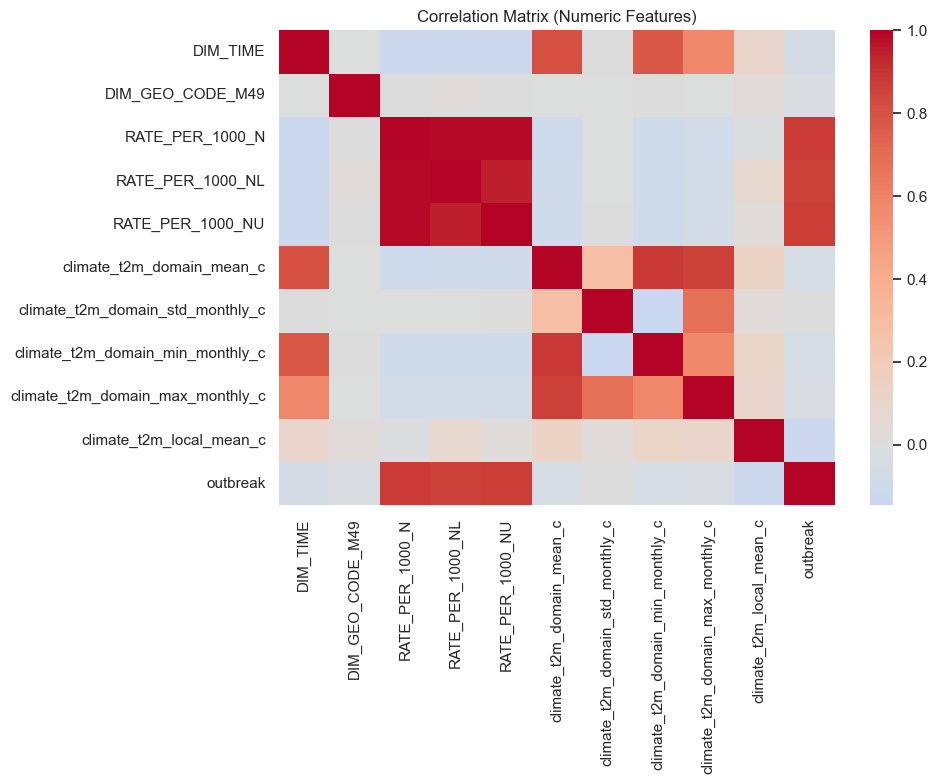

In [6]:
# ============================
# Exploratory Data Analysis (EDA)
# ============================

print("DataFrame info:")
print(df.info())

print("\nNumeric summary statistics:")
display(df.describe(include=[np.number]))

print("\nNon-numeric columns:")
display(df.select_dtypes(exclude=[np.number]).columns.tolist())

print(f"\nTarget '{TARGET_COL}' distribution:")
print(df[TARGET_COL].value_counts())
print("\nTarget proportions:")
print(df[TARGET_COL].value_counts(normalize=True))

# Correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation Matrix (Numeric Features)")
    plt.tight_layout()
    plt.show()

## Feature Engineering & Preprocessing

We now prepare the data for modeling.

Steps:

1. **Split features and target**:
   - `X` = all columns except `outbreak`
   - `y` = `outbreak`

2. **Automatically identify numeric and categorical features**:
   - Numeric: `df.select_dtypes(include=[np.number])`
   - Categorical: all other columns

3. **Build a `ColumnTransformer` for preprocessing**:
   - Numeric pipeline:
     - `SimpleImputer(strategy="median")`
     - `StandardScaler()`
   - Categorical pipeline:
     - `SimpleImputer(strategy="most_frequent")`
     - `OneHotEncoder(handle_unknown="ignore")`

4. Combine preprocessing and model in a single `Pipeline` to avoid manual scaling
   and feature-name mismatches.

In [7]:
# ============================
# Feature Engineering & Preprocessing
# ============================

# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

# Preprocessing for numeric data
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Preprocessing for categorical data
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# ColumnTransformer to apply the appropriate transformations to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("\nPreprocessing pipeline (ColumnTransformer) defined.")

Numeric features:
['DIM_TIME', 'DIM_GEO_CODE_M49', 'RATE_PER_1000_N', 'RATE_PER_1000_NL', 'RATE_PER_1000_NU', 'climate_t2m_domain_mean_c', 'climate_t2m_domain_std_monthly_c', 'climate_t2m_domain_min_monthly_c', 'climate_t2m_domain_max_monthly_c', 'climate_t2m_local_mean_c']

Categorical features:
['IND_ID', 'IND_CODE', 'IND_UUID', 'IND_PER_CODE', 'DIM_TIME_TYPE', 'DIM_GEO_CODE_TYPE', 'DIM_PUBLISH_STATE_CODE', 'IND_NAME', 'GEO_NAME_SHORT']

Preprocessing pipeline (ColumnTransformer) defined.


In [8]:
# ============================
# Model Training (RandomForestClassifier)
# ============================

from sklearn.utils import class_weight

# Train/test split (stratify by target to handle imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size : {X_test.shape[0]} rows")

# Compute class weights to help with class imbalance (optional but often useful)
classes = np.unique(y_train)
cw = class_weight.compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {cls: w for cls, w in zip(classes, cw)}
print("\nClass weights used for RandomForest:")
print(class_weights)

# Define the RandomForestClassifier
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight=class_weights,
    n_jobs=-1,
)

# Build the full Pipeline: preprocessing + model
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_clf),
    ]
)

# Fit the pipeline on the training data
print("\nFitting RandomForest Pipeline...")
rf_pipeline.fit(X_train, y_train)
print("Model training complete.")

Train size: 1897 rows
Test size : 813 rows

Class weights used for RandomForest:
{np.int64(0): np.float64(0.7307395993836672), np.int64(1): np.float64(1.5834724540901504)}

Fitting RandomForest Pipeline...
Model training complete.


## Model Evaluation

We evaluate the trained RandomForest model using:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Confusion matrix** (visualized with seaborn)

We use `rf_pipeline.predict()` directly, which ensures that all preprocessing
is applied consistently to the test data.

Evaluation Metrics on Test Set:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       556
           1       1.00      1.00      1.00       257

    accuracy                           1.00       813
   macro avg       1.00      1.00      1.00       813
weighted avg       1.00      1.00      1.00       813



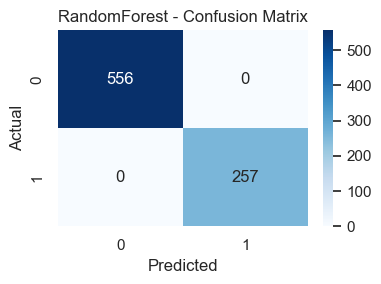

In [9]:
# ============================
# Model Evaluation
# ============================

# Predictions on the test set using the trained Pipeline
y_pred = rf_pipeline.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics on Test Set:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("RandomForest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Save Trained Model

We save the **entire Pipeline** (preprocessing + RandomForest model) using `joblib` to:

`outputs/malaria_outbreak_random_forest.joblib`

This allows us to perform **automatic prediction** later without
rebuilding or re-fitting the model, and **without manual scaling**.

In [10]:
# ============================
# Save Trained Model
# ============================

bundle = {
    "pipeline": rf_pipeline,
    "feature_names": X.columns.tolist(),  # original feature names before preprocessing
}

joblib.dump(bundle, MODEL_PATH)
print(f"Saved trained Pipeline bundle to: {MODEL_PATH}")

Saved trained Pipeline bundle to: outputs\malaria_outbreak_random_forest.joblib


## Automatic Prediction Example

In this final section, we demonstrate **automatic prediction**:

1. Load the saved Pipeline bundle from disk.
2. Select an example sample from the original dataset (excluding `outbreak`).
3. Run `pipeline.predict()` directly on a pandas DataFrame.
4. Display the predicted outbreak risk for the example.

This simulates how you can deploy the trained model for new, unseen data.

In [11]:
# ============================
# Automatic Prediction Example
# ============================

# Load the saved pipeline bundle
if not os.path.isfile(MODEL_PATH):
    raise FileNotFoundError(
        f"Saved model bundle not found at '{MODEL_PATH}'. "
        "Run the training cells above first."
    )

loaded_bundle = joblib.load(MODEL_PATH)
loaded_pipeline = loaded_bundle["pipeline"]
loaded_feature_names = loaded_bundle["feature_names"]

print("Loaded Pipeline bundle from disk.")
print("Feature names stored in bundle:")
print(loaded_feature_names)

# Create an example sample automatically from the dataset
# Here we simply take the first row of X (features only).
example_sample = X.iloc[[0]].copy()  # keep as DataFrame

print("\nExample sample (first row of feature set):")
display(example_sample)

# IMPORTANT:
# We do NOT call scaler/encoder manually.
# All preprocessing is handled inside the Pipeline.
example_prediction = loaded_pipeline.predict(example_sample)[0]

print("\nPredicted outbreak risk for example sample (0 = no outbreak, 1 = outbreak):")
print(int(example_prediction))

Loaded Pipeline bundle from disk.
Feature names stored in bundle:
['IND_ID', 'IND_CODE', 'IND_UUID', 'IND_PER_CODE', 'DIM_TIME', 'DIM_TIME_TYPE', 'DIM_GEO_CODE_M49', 'DIM_GEO_CODE_TYPE', 'DIM_PUBLISH_STATE_CODE', 'IND_NAME', 'GEO_NAME_SHORT', 'RATE_PER_1000_N', 'RATE_PER_1000_NL', 'RATE_PER_1000_NU', 'climate_t2m_domain_mean_c', 'climate_t2m_domain_std_monthly_c', 'climate_t2m_domain_min_monthly_c', 'climate_t2m_domain_max_monthly_c', 'climate_t2m_local_mean_c']

Example sample (first row of feature set):


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_1000_N,RATE_PER_1000_NL,RATE_PER_1000_NU,climate_t2m_domain_mean_c,climate_t2m_domain_std_monthly_c,climate_t2m_domain_min_monthly_c,climate_t2m_domain_max_monthly_c,climate_t2m_local_mean_c
0,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,364,COUNTRY,PUBLISHED,Malaria cases,Iran (Islamic Republic of),28.02882,28.02882,28.02882,24.855484,0.917594,23.585876,26.172485,NaN



Predicted outbreak risk for example sample (0 = no outbreak, 1 = outbreak):
0


---

### Summary

In this notebook, we:

- Loaded a malaria-related CSV dataset and automatically created a binary `outbreak` target.
- Performed basic exploratory data analysis.
- Built a **single scikit-learn Pipeline** that encapsulates:
  - Numeric and categorical preprocessing via `ColumnTransformer`.
  - A `RandomForestClassifier` with class balancing.
- Evaluated the model using standard classification metrics and a confusion matrix.
- Saved the trained Pipeline to disk for reuse.
- Demonstrated **automatic prediction** using `pipeline.predict()` directly on a pandas DataFrame.

This structure can be integrated into an undergraduate final year project as both
a methodological and practical implementation component of a machine learning-based
malaria outbreak prediction model.